<a href="https://colab.research.google.com/github/Kunj-7007/AI_ML_Workshop_LDRP/blob/day2/ML_EmissionProblem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix , classification_report
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
#Load the dataset
data=pd.read_csv('/content/emissions_reduction_data.csv')
#display first few rows
print (data.head())
#check for missing value
print(data.isnull().sum())




   energy_efficiency  renewable_ratio  technology_cost  emission_reduction
0          68.727006         0.373641      7569.984799                   0
1          97.535715         0.332912      2660.607960                   0
2          86.599697         0.176154      4119.757249                   0
3          79.932924         0.607267      6969.525732                   1
4          57.800932         0.476624      5338.804101                   0
energy_efficiency     0
renewable_ratio       0
technology_cost       0
emission_reduction    0
dtype: int64


In [ ]:
#To show number of rows and colomuns
print(data.shape)


(10000, 4)


In [13]:
#Define features and target variable
x=data[['energy_efficiency','renewable_ratio','technology_cost']]
y=data['emission_reduction']  #1 for effective reduction , 0 otherwise

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)



In [15]:
#set k
k=5
model=KNeighborsClassifier(n_neighbors=k)
model.fit(x_train,y_train)

KNeighborsClassifier()

In [17]:
y_pred=model.predict(x_test)

In [21]:
y_pred

array([0, 1, 0, ..., 0, 0, 0])

In [30]:
#Accurracy
accuracy_score=accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy_score}")

Accuracy: 0.99


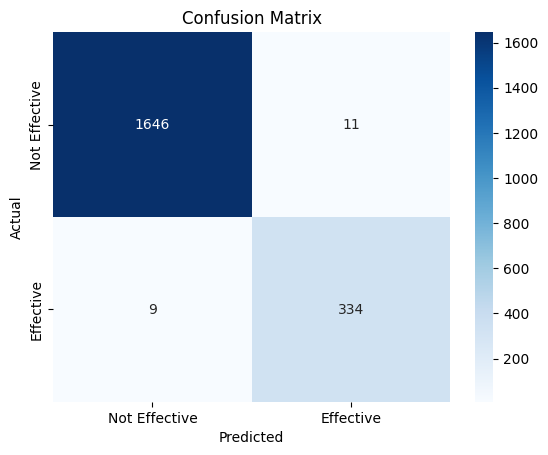

In [38]:
#Confusion matirx
conf_matrix=confusion_matrix(y_test,y_pred)
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Not Effective','Effective'],
            yticklabels=['Not Effective','Effective']
            )
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [39]:
#Classification report
print (classification_report(y_test,y_pred , target_names=['Not Effective','Effective']))

               precision    recall  f1-score   support

Not Effective       0.99      0.99      0.99      1657
    Effective       0.97      0.97      0.97       343

     accuracy                           0.99      2000
    macro avg       0.98      0.98      0.98      2000
 weighted avg       0.99      0.99      0.99      2000

